In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import h5py


In [2]:
def h5_to_dataframe(file_path, dataframe):
    ''' 
    Function for converting h5 file to a pandas dataframe for analysis 
    file_path: path to the h5 file, must be a string
    Dataframe_name: name of the pre-defined dataframe
    
    '''
    with h5py.File(file_path, mode='r') as file:
        tasks_group = file['tasks']
    
        keys = list(tasks_group.keys())
        keys.remove('visc_dissip')
        keys.remove('Reavg')
        time = np.array(file['scales']['sim_time'])
        for key in keys:
            name = np.array(file['tasks'][key][:,0,0])
            #print(name)
            dataframe[key] = name.tolist()

        dataframe['time'] = time.tolist()

    return dataframe

In [3]:
dataframes = []
dataframes2 = []
dataframes3 = []
for exponent in range(4, 9):  # 1e4 to 1e9
    for v in [1, 3, 5, 8]:
        var_name = f"R_{v}e{exponent}"
        globals()[var_name] = pd.DataFrame()
        dataframes.append(globals()[var_name])

        var_name2 = f"R2_{v}e{exponent}"
        globals()[var_name2] = pd.DataFrame()
        dataframes2.append(globals()[var_name2])

        var_name3 = f"R3_{v}e{exponent}"
        globals()[var_name3] = pd.DataFrame()
        dataframes3.append(globals()[var_name3])
        
values = [1, 3, 5, 8]
rayleigh_nums = []
file_path = []
file_path2 = []
file_path3 = []

for power in range(4, 9):  # From 10^4 to 10^9
    base = 10**power
    for v in values:
        rayleigh_nums.append(v * base)
        file_path.append(f"No_slip_data/NS_analysis_{v * base:.0e}/NS_analysis_{v * base:.0e}_s1.h5")
        file_path2.append(f"No_slip_data/NS_analysis2_{v * base:.0e}/NS_analysis2_{v * base:.0e}_s1.h5")
        file_path3.append(f"No_slip_data/NS_analysis3_{v * base:.0e}/NS_analysis3_{v * base:.0e}_s1.h5")


dfs = [dataframes, dataframes2, dataframes3]
file_paths = [file_path, file_path2, file_path3]

for x, df in enumerate(dfs):
    for a, i in enumerate(df):
        h5_to_dataframe(file_paths[x][a], i)
    


df_clean = []

for df in dfs:
    for x, i in enumerate(df):
        if len(i) == 800:
            Ral_num = np.ones(800)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)
        else:
            i = i.drop(i.tail(1).index)
            Ral_num = np.ones(800)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)

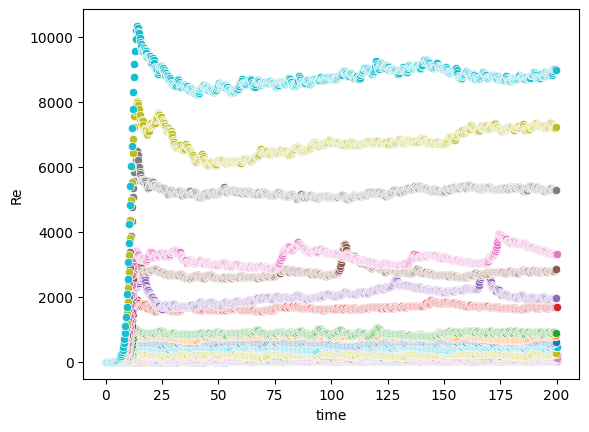

In [4]:
for frame in dataframes:
    sns.scatterplot(x = frame['time'], y = frame['Re'])

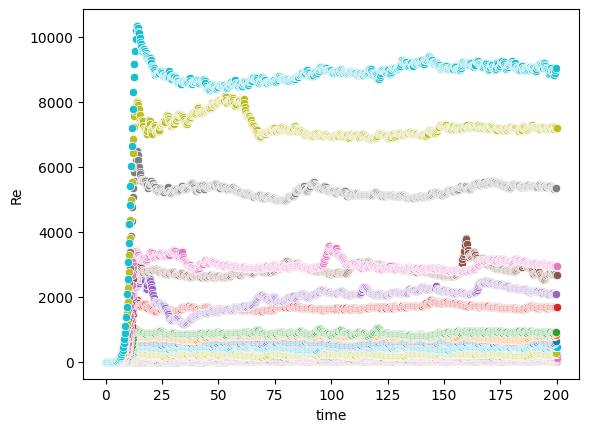

In [5]:
for frame in dataframes2:
    sns.scatterplot(x = frame['time'], y = frame['Re'])

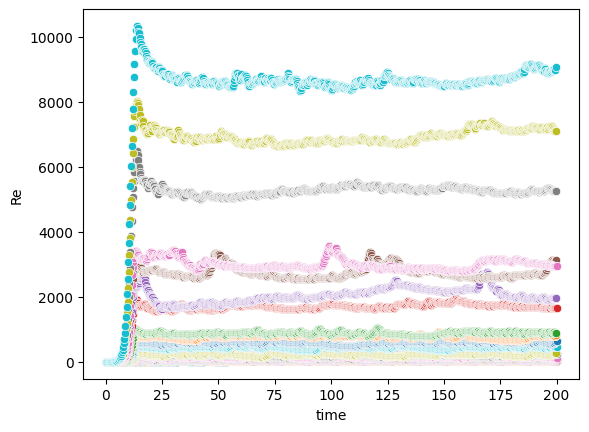

In [6]:
for frame in dataframes3:
    sns.scatterplot(x = frame['time'], y = frame['Re'])